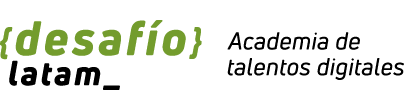



# <center><strong><font color="green">Distribución normal</font></strong></center>

## <strong><font color="green">Modelando con la distribución normal</font></strong>
Veremos como la distribución normal permite modelar algunos conjuntos de datos. Para ello necesitaremos importar algunas librerías y un conjunto de datos

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

dataset = pd.read_csv('height_weight.csv')

In [3]:
dataset.count()

Gender    10000
Height    10000
Weight    10000
dtype: int64

In [4]:
dataset.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


El dataset contiene los datos de genero, estatura (en pulgadas) y peso (en libras) de 10000 personas. Veremos algunos indicadores para la altura.

In [5]:
dataset['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [6]:
dataset.shape

(10000, 3)

Si construimos un histograma de los datos obtenemos lo siguiente:

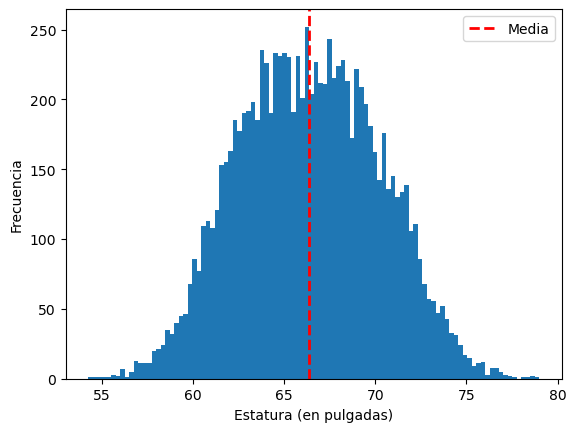

In [10]:
alturas=dataset['Height'].dropna()
media=np.mean(alturas)
plt.hist(alturas, bins=100)
plt.axvline(x=media, color='red', linestyle='--', linewidth=2, label='Media')
plt.xlabel('Estatura (en pulgadas)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

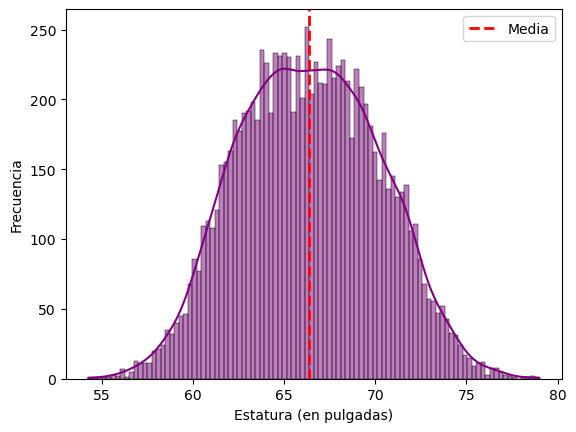

In [11]:
sns.histplot(alturas, bins=100, kde = True, color='purple')
plt.axvline(x=media, color='red', linestyle='--', linewidth=2, label='Media')
plt.xlabel('Estatura (en pulgadas)')
plt.ylabel('Frecuencia')
plt.legend()

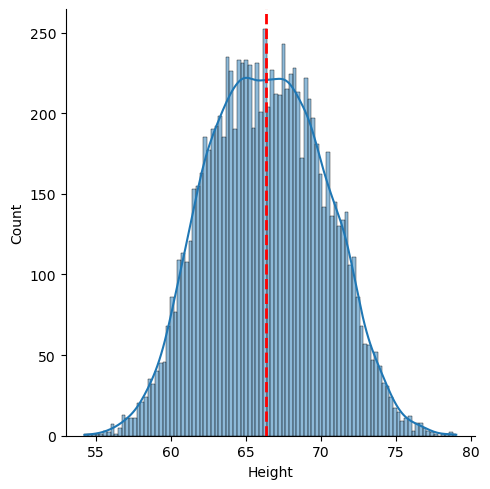

In [13]:
sns.displot(alturas, bins=100, kde=True)
plt.axvline(x=media, color='red', linestyle='dashed', linewidth=2, label='Media')

In [14]:
dataset.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


Podemos observar que la distribución de los datos es bastante simétrica respecto de la media.

- ¿Cómo podríamos calcular la probabilidad de que una persona escogida al azar mida 70 pulgadas o menos?



In [15]:
len(alturas)

10000

In [16]:
alturas.min()

54.2631333250971

In [17]:
alturas.max()

78.9987423463896

Veremos ahora como un modelo de distribucion normal puede ayudarnos a modelar esta situación.

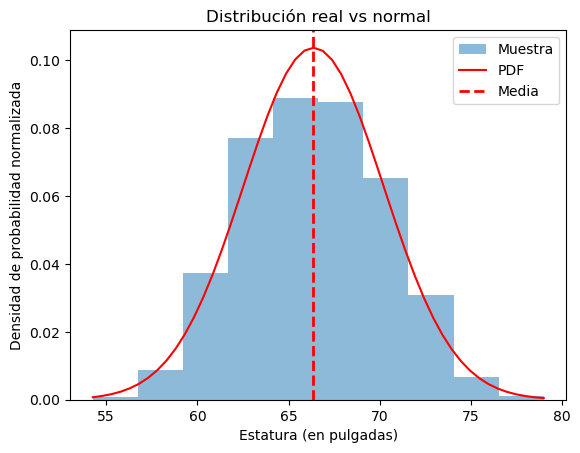

In [37]:
#Calculamos la media y la desviación estándar de los datos, además de los valores máximo y mínimo para graficar.
mu=alturas.mean()
sigma=alturas.std()
minimo=alturas.min()
maximo=alturas.max()

#Creamos un arreglo de valores equidistantes entre los valores mínimo y máximo, utilizando linspace
x = np.linspace(minimo, maximo)

#Creamos una función, llamada pdf, que calcula el valor de la función de distribución de probabilidad normal, con los parámetros dados
# Notemos que "sigma" funciona como "escala"
pdf = norm.pdf(x, loc=mu, scale=sigma) #funcion de densidad de probabilidad


# Histograma de los datos. El parámetro "density=True" va a construir el histograma haciendo que la suma de todas las áreas de las barras sea igual a 1, para que podamos representar las probabilidades
plt.hist(alturas, bins=10, density=True, alpha=0.5, label='Muestra')#alpha=0.5 da un 50% de transparencia

plt.plot(x, pdf, color='red', label='PDF') #Graficamos la distribución normal
plt.xlabel('Estatura (en pulgadas)')
plt.ylabel('Densidad de probabilidad normalizada')
plt.title('Distribución real vs normal')
plt.axvline(x=media, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.legend()
plt.show()


In [23]:
media

66.36755975482124

/var/folders/v4/7dd1ltfn517dxr1cpnssshx00000gn/T/ipykernel_9801/3118918380.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(alturas, bins=20, kde=True)


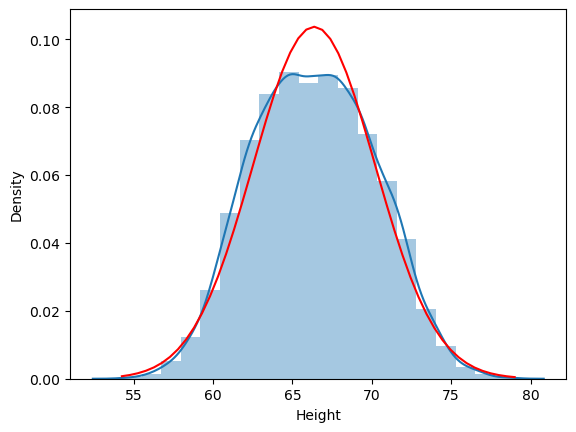

In [24]:
sns.distplot(alturas, bins=20, kde=True)
plt.plot(x, pdf, color='red', label='PDF') #Graficamos la distribución normal

<Axes: xlabel='Height', ylabel='Count'>

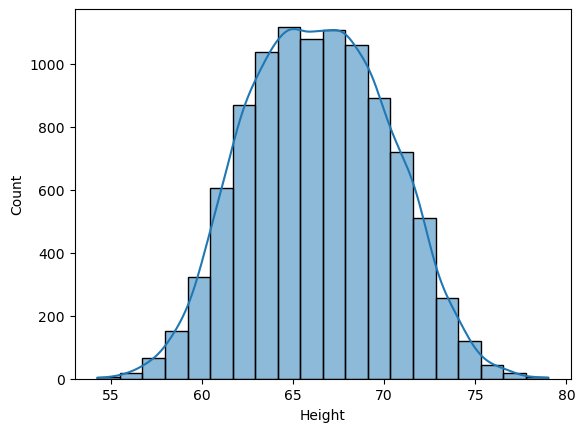

In [25]:
sns.histplot(alturas, bins=20, kde=True)

In [22]:
pdf

array([0.00073539, 0.00110165, 0.00162215, 0.00234782, 0.00334012,
       0.00467071, 0.00641989, 0.00867354, 0.01151832, 0.01503508,
       0.01929062, 0.02432824, 0.03015777, 0.03674613, 0.04400964,
       0.05180934, 0.05995042, 0.06818679, 0.07623111, 0.08376993,
       0.0904832 , 0.09606644, 0.10025346, 0.10283737, 0.10368752,
       0.10276044, 0.10010351, 0.09585099, 0.09021272, 0.08345703,
       0.07588955, 0.06783049, 0.05959254, 0.05146153, 0.04368149,
       0.03644485, 0.02988813, 0.02409269, 0.01908955, 0.01486723,
       0.01138121, 0.00856388, 0.00633398, 0.00460476, 0.00329049,
       0.00231121, 0.00159566, 0.00108284, 0.0007223 , 0.00047358])

In [19]:
x

array([54.26313333, 54.76794167, 55.27275002, 55.77755837, 56.28236671,
       56.78717506, 57.29198341, 57.79679176, 58.3016001 , 58.80640845,
       59.3112168 , 59.81602515, 60.32083349, 60.82564184, 61.33045019,
       61.83525854, 62.34006688, 62.84487523, 63.34968358, 63.85449193,
       64.35930027, 64.86410862, 65.36891697, 65.87372531, 66.37853366,
       66.88334201, 67.38815036, 67.8929587 , 68.39776705, 68.9025754 ,
       69.40738375, 69.91219209, 70.41700044, 70.92180879, 71.42661714,
       71.93142548, 72.43623383, 72.94104218, 73.44585053, 73.95065887,
       74.45546722, 74.96027557, 75.46508391, 75.96989226, 76.47470061,
       76.97950896, 77.4843173 , 77.98912565, 78.493934  , 78.99874235])

In [20]:
x[1]-x[0]

0.5048083473733129

In [21]:
x[2]-x[1]

0.50480834737332

In [26]:
x[2]+ (x[1]-x[0])

55.77755836721705

In [27]:
x[3]

55.77755836721705

¿Y si comparamos ahora los pesos, para hombres y mujeres por separado? Vamos a extraer los datos

In [28]:
hombres=dataset[dataset['Gender']=='Male']['Weight']
mujeres=dataset[dataset['Gender']=='Female']['Weight']

Definiremos ahora una función que nos permita modelar un conjunto de datos con a distribución normal

In [29]:
def get_psd(x):
  mu=x.mean()
  sigma=x.std()
  minimo=x.min()
  maximo=x.max()
  x = np.linspace(minimo, maximo)
  pdf = norm.pdf(x, loc=mu, scale=sigma)
  return(x,pdf)



Con esto, ya podemos hacer nuestra comparación

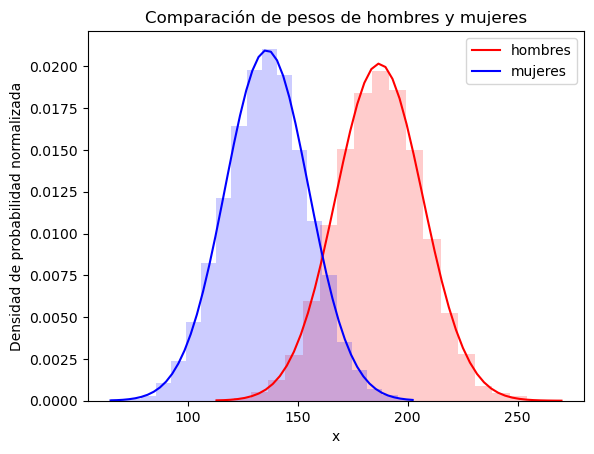

In [30]:
x,pdf=get_psd(hombres)
plt.plot(x , pdf, color='red', label='hombres')

x,pdf=get_psd(mujeres)
plt.plot(x , pdf, color='blue', label='mujeres')

plt.hist(hombres, bins=20, density=True, alpha=0.2, color='red')

plt.hist(mujeres, bins=20, density=True, alpha=0.2, color='blue')

plt.xlabel('x')
plt.ylabel('Densidad de probabilidad normalizada')
plt.title('Comparación de pesos de hombres y mujeres')
plt.legend()
plt.show()

In [31]:
x, y = [20,30]

In [32]:
x

20

In [33]:
y

30

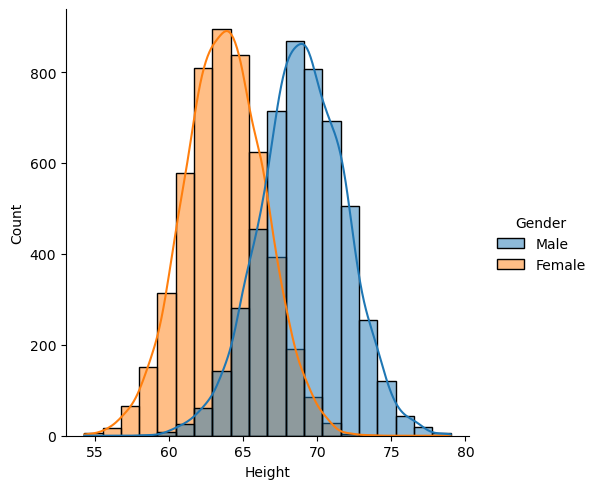

In [36]:
sns.displot(dataset, x='Height', bins=20, kde=True, hue='Gender')

## <strong><font color="green">Parámetros la distribución normal</font></strong>

¿Cuál puede ser la importancia de los parámetros de una distribución normal? Como hemos mencionado, la media de los datos constituye un **eje de simetria** de la curva. Mientras mayor sea esta media, este eje estará más desplazado hacia la derecha. En el gráfico anterior puedes ver que el promedio para los hombres es mayor, lo que hace que el gráfico esté desplazado hacia la derecha en comparación al de las mujeres.

Para analizar el rol que cumple la desviación estándar, veremos algunos ejemplos de distribuciones normales con la misma media pero diferentes desviaciones.

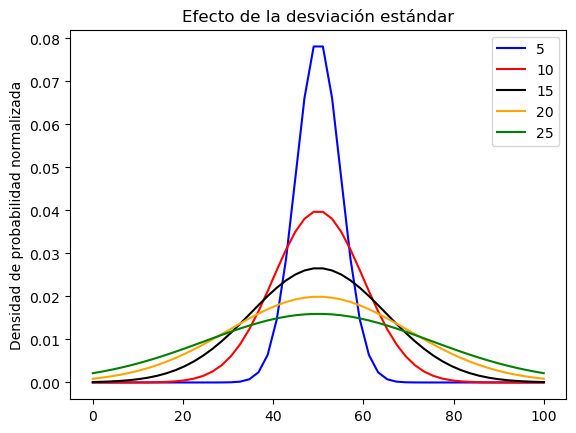

In [38]:
x = np.linspace(0, 100)# consideraremos un rango de valores entre 0 y 100

desv={5:'blue',10:'red',15:'black',20:'orange',25:'green'}

for clave,valor in desv.items():
  pdf = norm.pdf(x, loc=50, scale=clave)
  plt.plot(x, pdf, color=valor, label=clave)

plt.ylabel('Densidad de probabilidad normalizada')
plt.title('Efecto de la desviación estándar')
plt.legend()
plt.show()

¿Qué ocurre cuando aumenta el valor de sigma?

## <strong><font color="green">Aplicación la distribución normal</font></strong>

Considerando el modelamiento anterior, vamos a comparar los resultados "reales" (es decir, considerando la lista de datos) con lo que predice un modelo basado en la distribución normal. Específicamente, nos preguntaremos ¿cuál es la probabilidad de que una persona al azar mida 72 pulgadas o menos?

Nuestra primera alternativa es determinar a qué percentil corresponde 72 en el conjunto de datos. Para esto necesitaremos cargar una librería.


In [39]:
from scipy.stats import percentileofscore

print(percentileofscore(alturas, 72))


92.71000000000001


Es decir, un 92,7% de las personas de la muestra mide 72 puldadas o menos. O, lo que es igual, la probabilidad de escoger a una persona al azar que mida 72 pulgadas o menos es 0,927, aproximadamente.

¿Qué ocurre si consideramos la función normal definida por el promedio y la desviación estándar de los datos?

In [40]:

mu = np.mean(alturas)
sigma = np.std(alturas)

# Valor específico para el cual queremos calcular la probabilidad
valor = 72

# Calcular la probabilidad acumulada
probabilidad = norm.cdf(valor, loc=mu, scale=sigma)

print("La probabilidad de obtener un valor menor o igual a", valor, "es:", probabilidad)


La probabilidad de obtener un valor menor o igual a 72 es: 0.9284009209133961


¡Prueba con otros valores!

# DESAFIO

1. **Realiza una exploración de los datos, considerando sus tipos y los descriptivos
correspondientes.**

In [41]:
import pandas as pd
import os

In [42]:
os.listdir()

['.DS_Store',
 'baby.csv',
 ' 01 - Distribución normal.ipynb',
 '01 - Ley de los grandes numeros.ipynb',
 '.ipynb_checkpoints',
 'height_weight.csv']

In [43]:
df = pd.read_csv('baby.csv')

In [44]:
df.head()

,Unnamed: 0,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight,Maternal.Smoker
0,1,120,284,27,62,100,False
1,2,113,282,33,64,135,False
2,3,128,279,28,64,115,True
3,4,108,282,23,67,125,True
4,5,136,286,25,62,93,False


In [45]:
df.shape

(1174, 7)

In [46]:
df.drop(columns='Unnamed: 0', inplace=True)

In [47]:
df.head()

,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight,Maternal.Smoker
0,120,284,27,62,100,False
1,113,282,33,64,135,False
2,128,279,28,64,115,True
3,108,282,23,67,125,True
4,136,286,25,62,93,False


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Birth.Weight               1174 non-null   int64
 1   Gestational.Days           1174 non-null   int64
 2   Maternal.Age               1174 non-null   int64
 3   Maternal.Height            1174 non-null   int64
 4   Maternal.Pregnancy.Weight  1174 non-null   int64
 5   Maternal.Smoker            1174 non-null   bool 
dtypes: bool(1), int64(5)
memory usage: 47.1 KB


In [49]:
df.isna().sum()

Birth.Weight                 0
Gestational.Days             0
Maternal.Age                 0
Maternal.Height              0
Maternal.Pregnancy.Weight    0
Maternal.Smoker              0
dtype: int64

In [50]:
df.describe()

,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight
count,1174.000000,1174.000000,1174.000000,1174.000000,1174.000000
mean,119.462521,279.101363,27.228279,64.049404,128.478705
std,18.328671,16.010305,5.817839,2.526102,20.734282
min,55.000000,148.000000,15.000000,53.000000,87.000000
25%,108.000000,272.000000,23.000000,62.000000,114.250000
50%,120.000000,280.000000,26.000000,64.000000,125.000000
75%,131.000000,288.000000,31.000000,66.000000,139.000000
max,176.000000,353.000000,45.000000,72.000000,250.000000


In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
df.corr()

,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight,Maternal.Smoker
Birth.Weight,1.000000,0.407543,0.026983,0.203704,0.155923,-0.246800
Gestational.Days,0.407543,1.000000,-0.053425,0.070470,0.023655,-0.060267
Maternal.Age,0.026983,-0.053425,1.000000,-0.006453,0.147322,-0.067772
Maternal.Height,0.203704,0.070470,-0.006453,1.000000,0.435287,0.017507
Maternal.Pregnancy.Weight,0.155923,0.023655,0.147322,0.435287,1.000000,-0.060281
Maternal.Smoker,-0.246800,-0.060267,-0.067772,0.017507,-0.060281,1.000000


<Axes: >

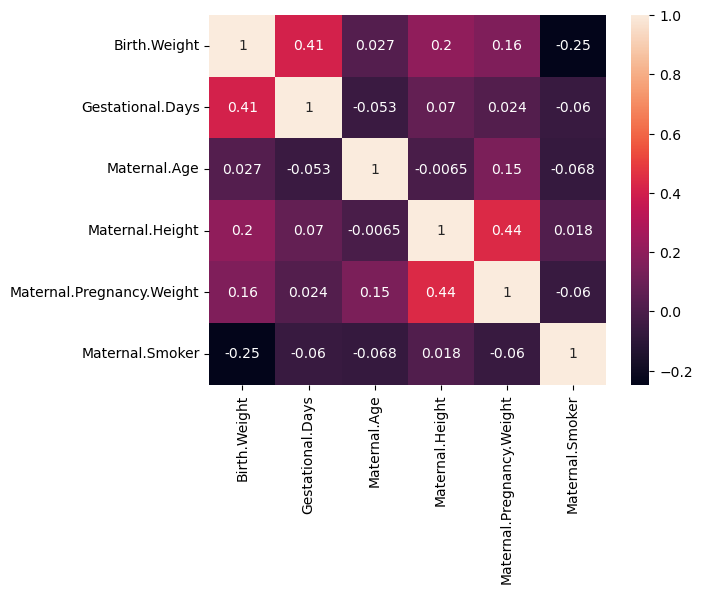

In [53]:
sns.heatmap(df.corr(), annot=True)

<Axes: xlabel='Birth.Weight', ylabel='Count'>

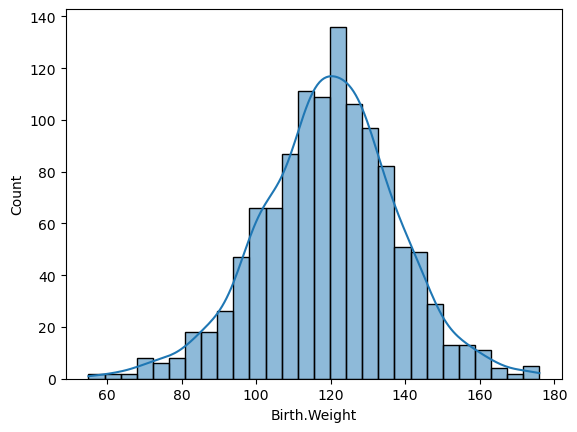

In [54]:
sns.histplot(df['Birth.Weight'], kde = True)

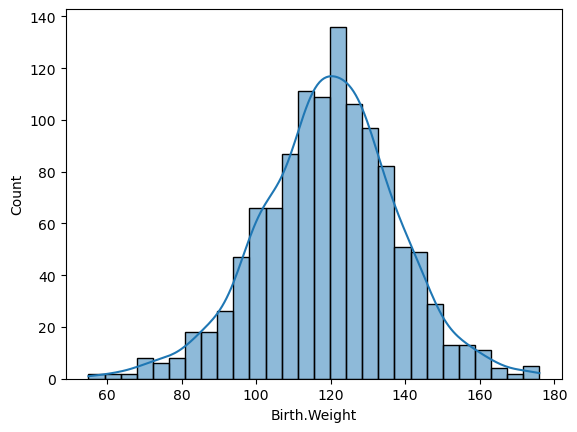

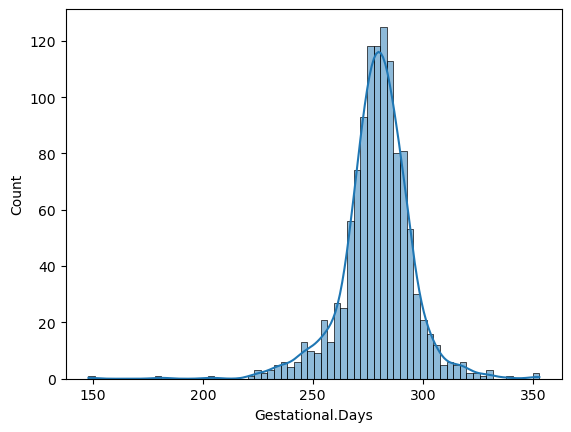

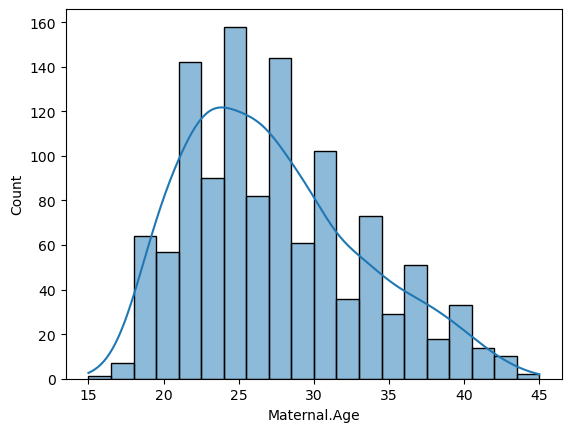

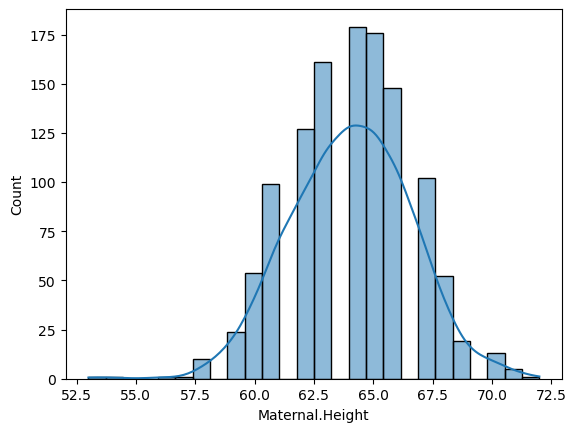

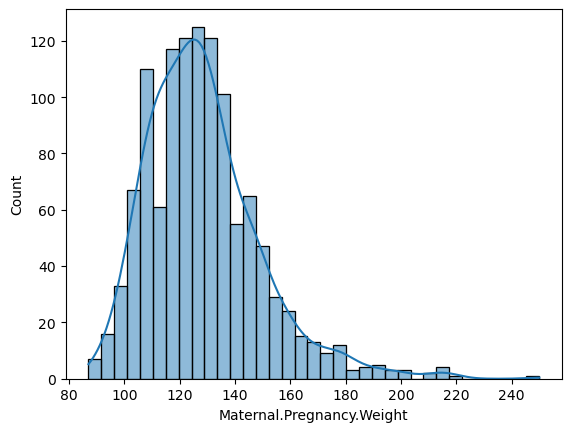

In [57]:
for columna in df.drop(columns='Maternal.Smoker').columns:
    sns.histplot(df[columna], kde = True)
    plt.show()

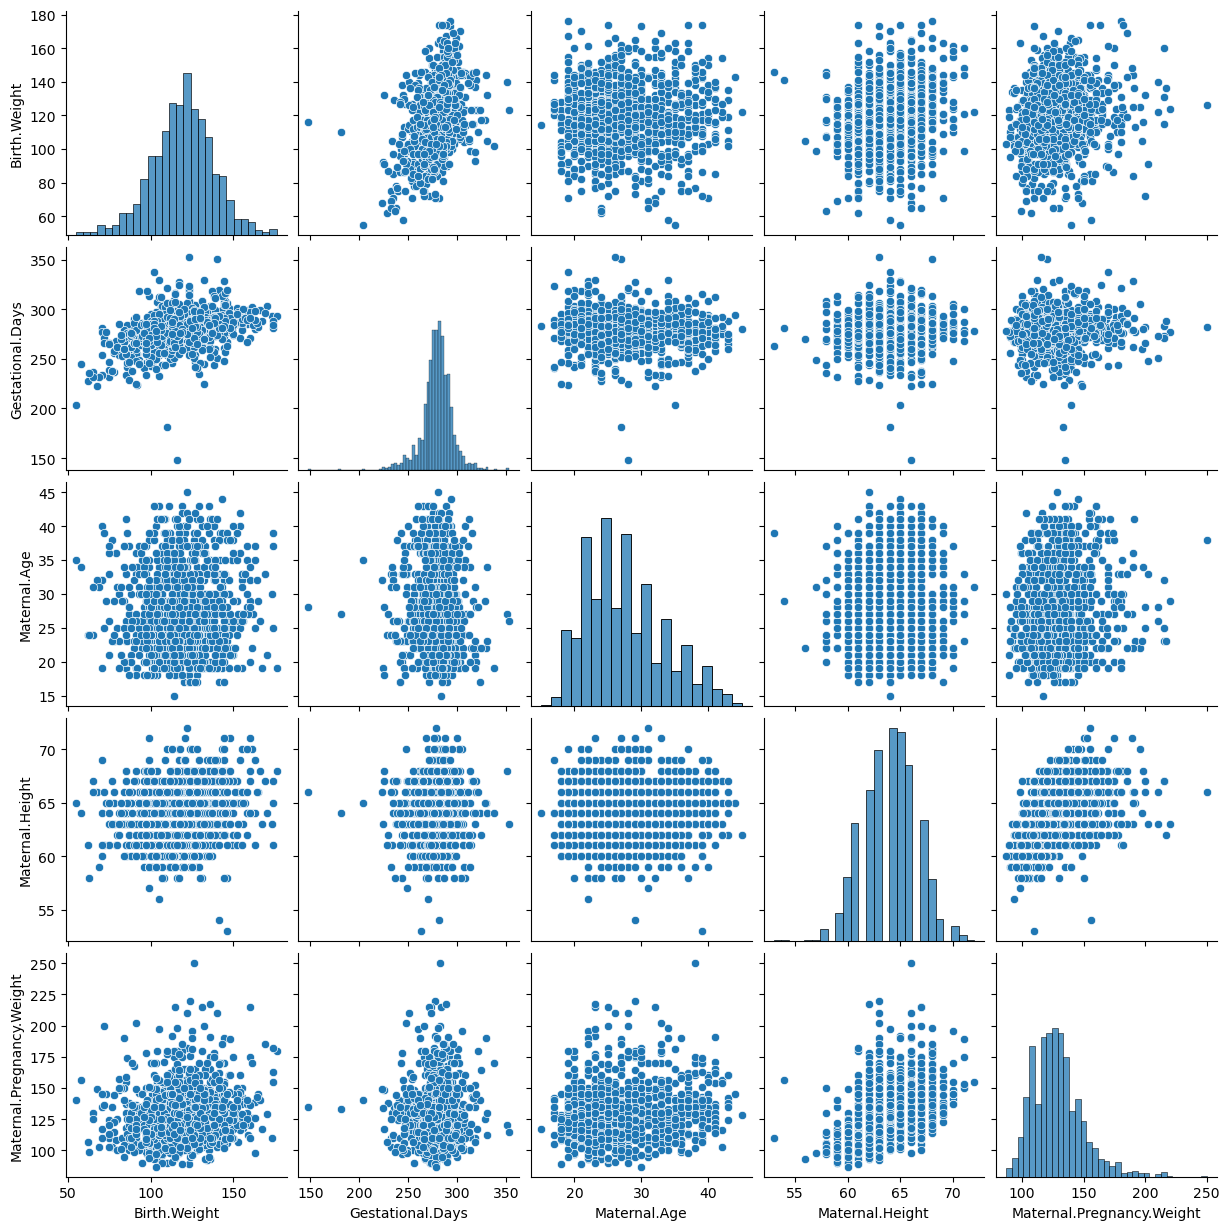

In [55]:
sns.pairplot(df.drop(columns='Maternal.Smoker'))

2. **Considera los pesos de los bebés. ¿Se puede decir que siguen una distribución
normal? Justifica tu respuesta creando los gráficos y modelos necesarios.**

In [58]:
mu=df['Birth.Weight'].mean()
sigma=df['Birth.Weight'].std()
minimo=df['Birth.Weight'].min()
maximo=df['Birth.Weight'].max()

#Creamos un arreglo de valores equidistantes entre los valores mínimo y máximo, utilizando linspace
x = np.linspace(minimo, maximo)

#Creamos una función, llamada pdf, que calcula el valor de la función de distribución de probabilidad normal, con los parámetros dados
# Notemos que "sigma" funciona como "escala"
pdf = norm.pdf(x, loc=mu, scale=sigma) #funcion de densidad de probabilidad

In [59]:
pdf

array([4.48511360e-05, 7.13870322e-05, 1.11578890e-04, 1.71262222e-04,
       2.58141568e-04, 3.82094812e-04, 5.55393980e-04, 7.92771492e-04,
       1.11124984e-03, 1.52965055e-03, 2.06770973e-03, 2.74475602e-03,
       3.57795398e-03, 4.58018040e-03, 5.75767633e-03, 7.10769429e-03,
       8.61642401e-03, 1.02575163e-02, 1.19915189e-02, 1.37664831e-02,
       1.55198903e-02, 1.71818972e-02, 1.86797223e-02, 1.99428188e-02,
       2.09083375e-02, 2.15262951e-02, 2.17638592e-02, 2.16082379e-02,
       2.10678215e-02, 2.01714322e-02, 1.89657784e-02, 1.75114229e-02,
       1.58777526e-02, 1.41375272e-02, 1.23616006e-02, 1.06143350e-02,
       8.95009617e-03, 7.41104489e-03, 6.02626208e-03, 4.81208639e-03,
       3.77342434e-03, 2.90572631e-03, 2.19730627e-03, 1.63171127e-03,
       1.18990657e-03, 8.52117021e-04, 5.99242280e-04, 4.13830489e-04,
       2.80646319e-04, 1.86901612e-04])

In [60]:
x

array([ 55.        ,  57.46938776,  59.93877551,  62.40816327,
        64.87755102,  67.34693878,  69.81632653,  72.28571429,
        74.75510204,  77.2244898 ,  79.69387755,  82.16326531,
        84.63265306,  87.10204082,  89.57142857,  92.04081633,
        94.51020408,  96.97959184,  99.44897959, 101.91836735,
       104.3877551 , 106.85714286, 109.32653061, 111.79591837,
       114.26530612, 116.73469388, 119.20408163, 121.67346939,
       124.14285714, 126.6122449 , 129.08163265, 131.55102041,
       134.02040816, 136.48979592, 138.95918367, 141.42857143,
       143.89795918, 146.36734694, 148.83673469, 151.30612245,
       153.7755102 , 156.24489796, 158.71428571, 161.18367347,
       163.65306122, 166.12244898, 168.59183673, 171.06122449,
       173.53061224, 176.        ])

/var/folders/v4/7dd1ltfn517dxr1cpnssshx00000gn/T/ipykernel_9801/3240846950.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Birth.Weight'], kde = True)


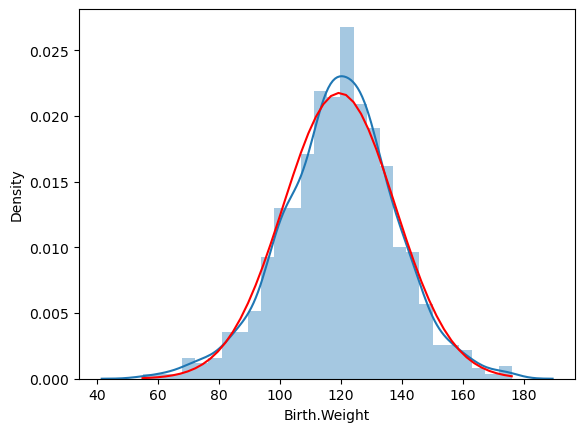

In [61]:
sns.distplot(df['Birth.Weight'], kde = True)
plt.plot(x, pdf, color='red', label='PDF') #Graficamos la distribución normal

Se aprecia que la curva de distribución de desidad de los pesos de los bebes se asemeja a una normal

3. **Considerando lo anterior, verifica el modelo de distribución normal de los pesos para
5 valores diferentes. Compara con los datos reales.**

In [62]:
#uso ejemplos de Júpiter anterior para ver el funcionamiento del código y más adelante implementarlo para los bebés
from scipy.stats import percentileofscore

print(percentileofscore(alturas, 72))

92.71000000000001


In [63]:
#uso ejemplos de Júpiter anterior para ver el funcionamiento del código y más adelante implementarlo para los bebés
mu = np.mean(alturas)
sigma = np.std(alturas)

# Valor específico para el cual queremos calcular la probabilidad
valor = 72

# Calcular la probabilidad acumulada
probabilidad = norm.cdf(valor, loc=mu, scale=sigma)

print("La probabilidad de obtener un valor menor o igual a", valor, "es:", probabilidad)

La probabilidad de obtener un valor menor o igual a 72 es: 0.9284009209133961


In [64]:
df['Birth.Weight'].describe()

count    1174.000000
mean      119.462521
std        18.328671
min        55.000000
25%       108.000000
50%       120.000000
75%       131.000000
max       176.000000
Name: Birth.Weight, dtype: float64

In [65]:
pesos_bebe = [100, 110, 120, 130, 150]

In [70]:
mu = np.mean(df['Birth.Weight'])
sigma = np.std(df['Birth.Weight'])
for peso in pesos_bebe:
    peso_en_la_data = percentileofscore(df['Birth.Weight'], peso)
    peso_teorico = norm.cdf(peso, loc=mu, scale=sigma)*100
    print(f'el percentil para un peso de {peso}:\n en la data ==> {peso_en_la_data}, teórico ==> {peso_teorico}')

el percentil para un peso de 100:
 en la data ==> 13.798977853492334, teórico ==> 14.404644056657334
el percentil para un peso de 110:
 en la data ==> 28.066439522998294, teórico ==> 30.275652232430904
el percentil para un peso de 120:
 en la data ==> 50.383304940374785, teórico ==> 51.170208077139534
el percentil para un peso de 130:
 en la data ==> 73.29642248722317, teórico ==> 71.74093902161573
el percentil para un peso de 150:
 en la data ==> 95.61328790459966, teórico ==> 95.22243380229664


In [71]:
peso_teorico

95.22243380229664

4. **Compara los pesos de los bebés de madres fumadoras y no fumadoras. ¿Qué
diferencias existen? Explica y construye los modelos correspondientes.**

In [72]:
df['Maternal.Smoker'].value_counts()

Maternal.Smoker
False    715
True     459
Name: count, dtype: int64

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Birth.Weight               1174 non-null   int64
 1   Gestational.Days           1174 non-null   int64
 2   Maternal.Age               1174 non-null   int64
 3   Maternal.Height            1174 non-null   int64
 4   Maternal.Pregnancy.Weight  1174 non-null   int64
 5   Maternal.Smoker            1174 non-null   bool 
dtypes: bool(1), int64(5)
memory usage: 47.1 KB


<Axes: xlabel='Birth.Weight', ylabel='Count'>

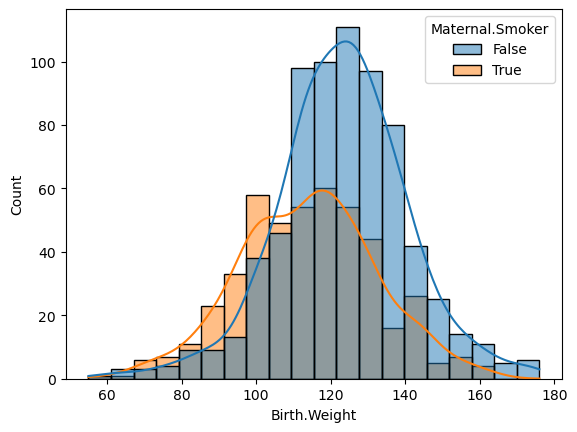

In [73]:
sns.histplot(df, x='Birth.Weight', bins=20, kde=True, hue='Maternal.Smoker')

In [75]:
madres_fumadoras=df[df['Maternal.Smoker']==True]['Birth.Weight']
madres_no_fumadoras=df[df['Maternal.Smoker']==False]['Birth.Weight']

In [76]:
def get_psd(x):
  mu=x.mean()
  sigma=x.std()
  minimo=x.min()
  maximo=x.max()
  x = np.linspace(minimo, maximo)
  pdf = norm.pdf(x, loc=mu, scale=sigma)
  return(x,pdf)

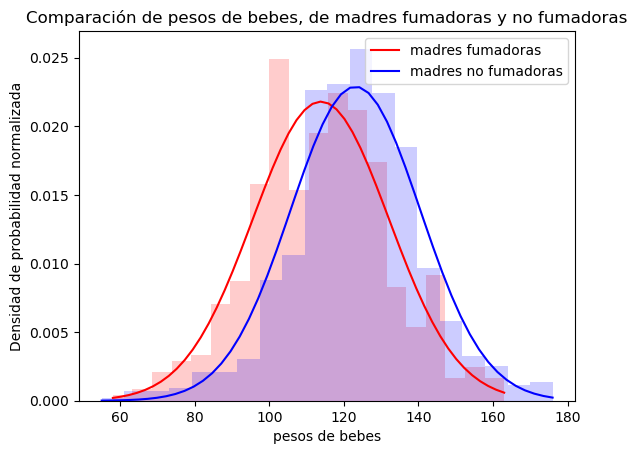

In [77]:
x,pdf=get_psd(madres_fumadoras)
plt.plot(x , pdf, color='red', label='madres fumadoras')

x,pdf=get_psd(madres_no_fumadoras)
plt.plot(x , pdf, color='blue', label='madres no fumadoras')

plt.hist(madres_fumadoras, bins=20, density=True, alpha=0.2, color='red')

plt.hist(madres_no_fumadoras, bins=20, density=True, alpha=0.2, color='blue')

plt.xlabel('pesos de bebes')
plt.ylabel('Densidad de probabilidad normalizada')
plt.title('Comparación de pesos de bebes, de madres fumadoras y no fumadoras')
plt.legend()
plt.show()

5. **Considerando los datos dados:**

● **Calcula la probabilidad de que una madre escogida al azar fume.**

In [78]:
df.head()

,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight,Maternal.Smoker
0,120,284,27,62,100,False
1,113,282,33,64,135,False
2,128,279,28,64,115,True
3,108,282,23,67,125,True
4,136,286,25,62,93,False


In [79]:
df['Maternal.Smoker'].value_counts('%')[True]

0.3909710391822828

In [80]:
p_madres_fumadoras = df['Maternal.Smoker'].sum()/df.shape[0]
p_madres_fumadoras

0.3909710391822828

● **A partir del valor anterior, construye un modelo de distribución binomial que
modele el experimento correspondiente a escoger 5 madres al azar y observar
cuántas fuman.**

● **Utilizando este modelo, simula 1000 muestras de tamaño 8, y calcula sus medias
muestrales.**

● **Utilizando los datos directamente, extrae 1000 muestras de tamaño 8 y calcula
sus respectivas medias muestrales.**

In [81]:
import numpy as np

In [90]:
medias_teoricas_madres_fumadoras_al_azar=[]
for i in range(1000):
    medias_teoricas_madres_fumadoras_al_azar.append(np.mean(np.random.binomial(5,p_madres_fumadoras,size=8)))
medias_teoricas_madres_fumadoras_al_azar[0:10]

[1.5, 1.75, 2.0, 1.75, 2.5, 2.0, 2.0, 2.0, 1.75, 1.75]

In [83]:
medias_reales_madres_fumadoras_al_azar=[]
madres_fumadoras = df['Maternal.Smoker']
fuma = np.where(madres_fumadoras, 1, 0)
for k in range(1000):
    muestra = []
    for m in range(8):
        muestra.append(sum(np.random.choice(fuma, size=5, replace=False)))
    medias_reales_madres_fumadoras_al_azar.append(np.mean(muestra))
medias_reales_madres_fumadoras_al_azar[0:10]

[1.75, 2.125, 2.5, 2.0, 2.375, 2.0, 2.25, 1.875, 1.625, 2.375]

(array([0.008, 0.016, 0.04 , 0.144, 0.288, 0.368, 0.456, 0.8  , 0.736,
        0.936, 1.   , 0.992, 0.768, 0.6  , 0.44 , 0.192, 0.088, 0.08 ,
        0.032, 0.016]),
 array([0.75 , 0.875, 1.   , 1.125, 1.25 , 1.375, 1.5  , 1.625, 1.75 ,
        1.875, 2.   , 2.125, 2.25 , 2.375, 2.5  , 2.625, 2.75 , 2.875,
        3.   , 3.125, 3.25 ]),
 <BarContainer object of 20 artists>)

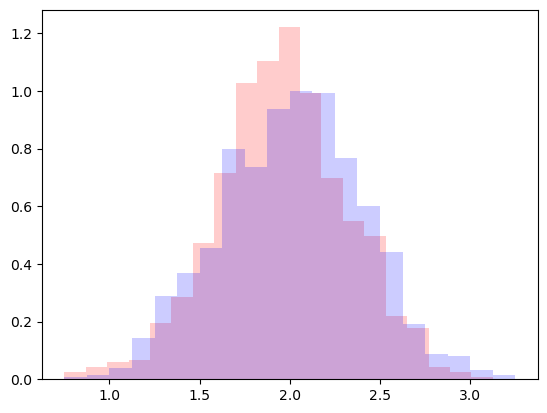

In [92]:
plt.hist(medias_teoricas_madres_fumadoras_al_azar, bins=20, density=True, alpha=0.2, color='red')

plt.hist(medias_reales_madres_fumadoras_al_azar, bins=20, density=True, alpha=0.2, color='blue')

(array([0.02526316, 0.04210526, 0.05894737, 0.06736842, 0.19368421,
        0.28631579, 0.47157895, 0.71578947, 1.02736842, 1.10315789,
        1.22105263, 0.99368421, 0.69894737, 0.54736842, 0.49684211,
        0.21894737, 0.17684211, 0.04210526, 0.02526316, 0.00842105]),
 array([0.75   , 0.86875, 0.9875 , 1.10625, 1.225  , 1.34375, 1.4625 ,
        1.58125, 1.7    , 1.81875, 1.9375 , 2.05625, 2.175  , 2.29375,
        2.4125 , 2.53125, 2.65   , 2.76875, 2.8875 , 3.00625, 3.125  ]),
 <BarContainer object of 20 artists>)

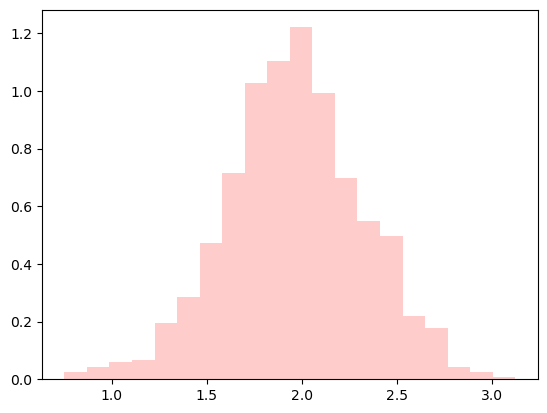

In [91]:
plt.hist(medias_teoricas_madres_fumadoras_al_azar, bins=20, density=True, alpha=0.2, color='red')

(array([0.008, 0.016, 0.04 , 0.144, 0.288, 0.368, 0.456, 0.8  , 0.736,
        0.936, 1.   , 0.992, 0.768, 0.6  , 0.44 , 0.192, 0.088, 0.08 ,
        0.032, 0.016]),
 array([0.75 , 0.875, 1.   , 1.125, 1.25 , 1.375, 1.5  , 1.625, 1.75 ,
        1.875, 2.   , 2.125, 2.25 , 2.375, 2.5  , 2.625, 2.75 , 2.875,
        3.   , 3.125, 3.25 ]),
 <BarContainer object of 20 artists>)

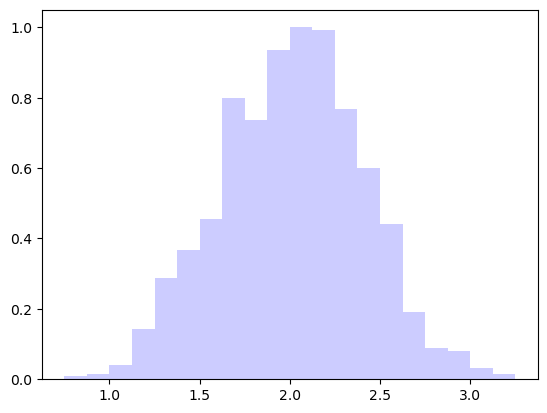

In [89]:
plt.hist(medias_reales_madres_fumadoras_al_azar, bins=20, density=True, alpha=0.2, color='blue')